In [2]:
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats
import os
from torchvision.datasets import ImageFolder
import pathlib
from PIL import Image
from hashlib import md5
import pandas as pd

In [3]:
plt.rcParams.update({
    "font.family": "Courier New",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 16
})

In [4]:
BASE_DATA_PATH = pathlib.Path("/srv/defectDetectionDataset/surfaceClassification")

# Baseline

In [5]:
dataset = ImageFolder(BASE_DATA_PATH / "baseline")

In [6]:
targets = np.array(dataset.targets)
num_classes = len(dataset.classes)
labels =["Bent",
  "Blackstained",
  "Cracked",
  "GapDemo",
  "MissingEnd",
  "NoDeficiencies",
  "Rust",
  "ScratchedSurface",
  "Silicatestain",
  "UnknownStains",
  "Unknown",
  "Waterstains"]

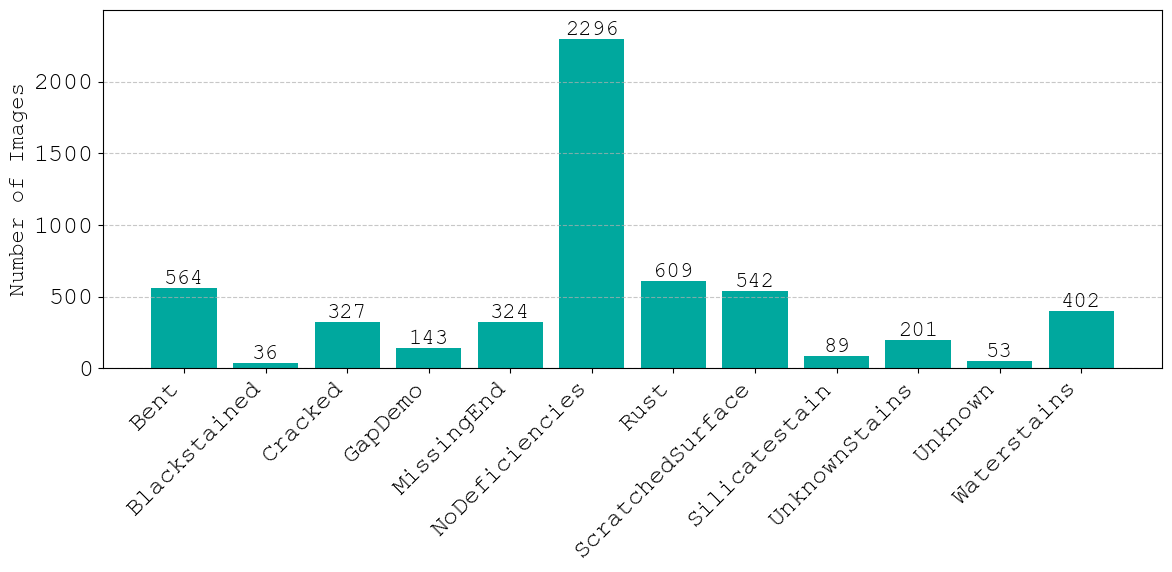

In [7]:
plt.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

fig = plt.figure(figsize=(12, 6))

plt.bar(np.arange(0, num_classes), [np.sum(targets == i) for i in range(num_classes)], color=(0.0, 0.66, 0.62))
for i in range(num_classes):
    plt.text(i, np.sum(targets == i), str(np.sum(targets == i)), ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(np.arange(0, 2500, 500))
plt.ylim(0, 2500)
plt.xticks(np.arange(0, num_classes), labels, rotation=45, ha='right')
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("plots/class_distribution_baseline.svg", bbox_inches='tight')
plt.show()

## Baseline performance

In [8]:
baseline_training_statistics = pd.read_csv("../logs/train/SurfaceDefectDetection/baseline/2026-02-20_23-01-25_mobile_s/summary/summary_statistics.csv")

In [9]:
metrics_df = baseline_training_statistics.copy()

macro_metrics = metrics_df[metrics_df["metric"].astype(str).str.endswith("macro")]
weighted_metrics = metrics_df[metrics_df["metric"].astype(str).str.endswith("weighted")]

macro_weighted_metrics = pd.concat([macro_metrics, weighted_metrics])
macro_weighted_metrics.sort_values(by=["metric"], inplace=True, ascending=True)
macro_weighted_metrics.reset_index(drop=True, inplace=True)

macro_weighted_metrics

,metric,mean,median,std,ci_lower,ci_upper,min,max
0,test/f1_macro,0.959773,0.962193,0.012053,0.951151,0.968395,0.940566,0.979609
1,test/f1_weighted,0.965322,0.967824,0.008678,0.959115,0.971530,0.952446,0.976716
2,test/precision_macro,0.967116,0.969594,0.010369,0.959699,0.974534,0.945680,0.982018
3,test/precision_weighted,0.965962,0.968201,0.008330,0.960004,0.971921,0.953916,0.976985
4,test/recall_macro,0.954355,0.956103,0.014249,0.944162,0.964548,0.926293,0.977574
5,test/recall_weighted,0.965385,0.967800,0.008600,0.959232,0.971537,0.952594,0.976744


In [10]:
baseline_clustered_training_statistics = pd.read_csv("../logs/train/SurfaceDefectDetection/baseline/2026-02-22_08-21-39_mobile_s_clustered/summary/summary_statistics.csv")

In [11]:
metrics_df = baseline_clustered_training_statistics.copy()

macro_metrics = metrics_df[metrics_df["metric"].astype(str).str.endswith("macro")]
weighted_metrics = metrics_df[metrics_df["metric"].astype(str).str.endswith("weighted")]

clustered_macro_weighted_metrics = pd.concat([macro_metrics, weighted_metrics])
clustered_macro_weighted_metrics.sort_values(by=["metric"], inplace=True, ascending=True)
clustered_macro_weighted_metrics.reset_index(drop=True, inplace=True)

clustered_macro_weighted_metrics

,metric,mean,median,std,ci_lower,ci_upper,min,max
0,test/f1_macro,0.861887,0.859497,0.021329,0.846629,0.877145,0.827796,0.907903
1,test/f1_weighted,0.874879,0.871633,0.012597,0.865868,0.883890,0.857987,0.897597
2,test/precision_macro,0.870318,0.868825,0.026291,0.851510,0.889126,0.838271,0.933226
3,test/precision_weighted,0.879454,0.876143,0.011931,0.870919,0.887988,0.862212,0.900792
4,test/recall_macro,0.868280,0.869543,0.020746,0.853439,0.883121,0.823488,0.893364
5,test/recall_weighted,0.875240,0.871995,0.012705,0.866152,0.884329,0.858173,0.897837


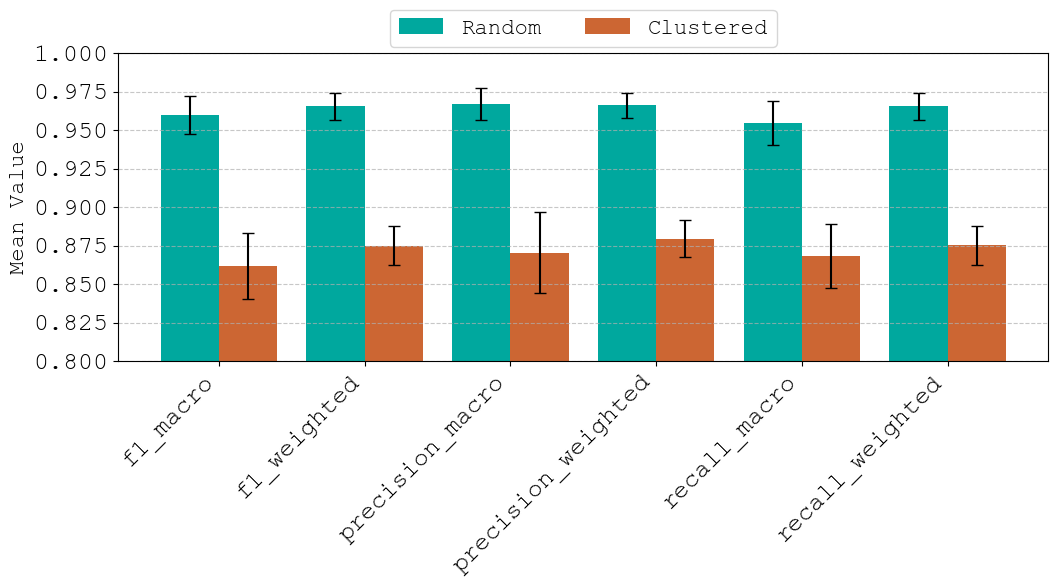

In [12]:
import matplotlib.pyplot as plt

# Prepare data for plotting
metrics = macro_weighted_metrics["metric"].values
macro_means = macro_weighted_metrics["mean"].values
clustered_means = clustered_macro_weighted_metrics["mean"].values

x = np.arange(len(metrics))

metric_names = [m.split("/")[-1] for m in metrics]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - 0.2, macro_means, width=0.4, label="Random", color=(0.0, 0.66, 0.62))
ax.bar(x + 0.2, clustered_means, width=0.4, label="Clustered", color=(0.8, 0.4, 0.2))
ax.errorbar(x - 0.2, macro_means, yerr=macro_weighted_metrics["std"].values, fmt='none', ecolor='black', capsize=4)
ax.errorbar(x + 0.2, clustered_means, yerr=clustered_macro_weighted_metrics["std"].values, fmt='none', ecolor='black', capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=45, ha="right")
ax.set_ylabel("Mean Value")
ax.set_ylim(0.8, 1.0)
ax.set_yticks(np.arange(0.8, 1.01, 0.025))
ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center',
                      ncols=2, borderaxespad=0.)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("plots/metrics_baseline_random_vs_clustered.svg", bbox_inches='tight')
plt.show()

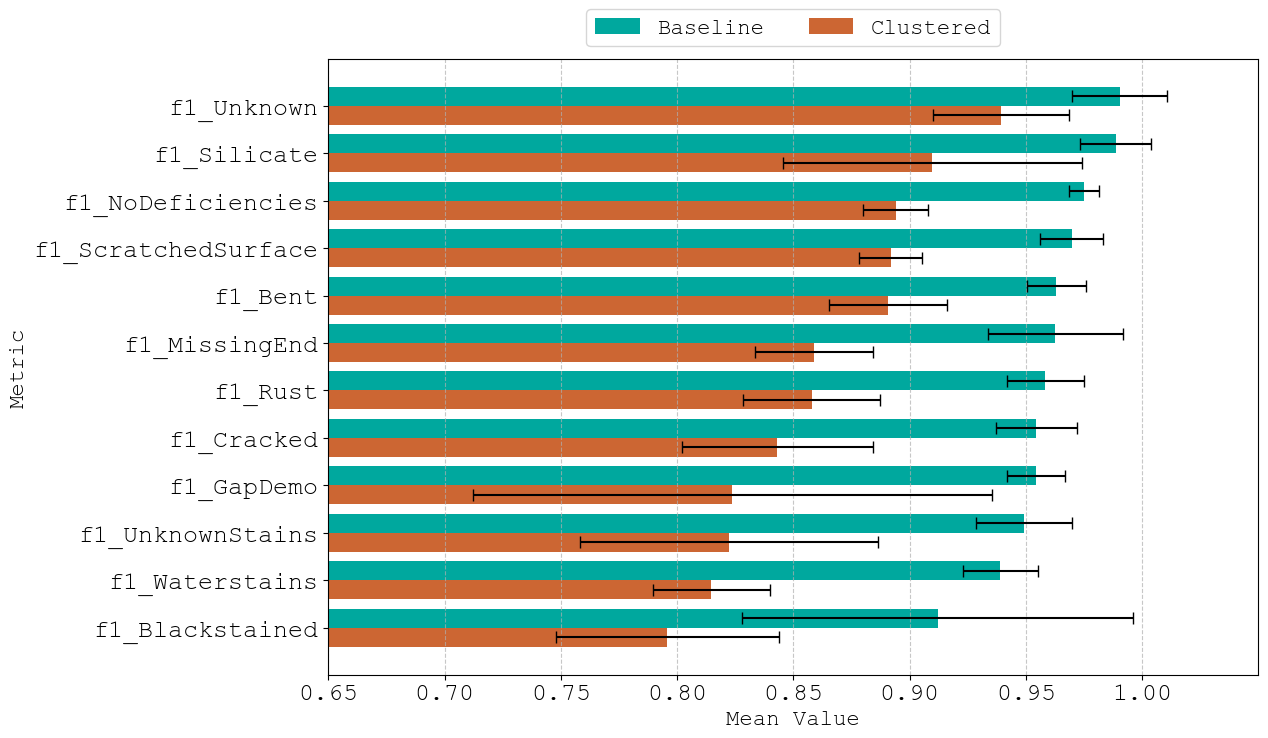

In [13]:
class_metrics_df = baseline_training_statistics.copy()
f1_df = class_metrics_df[class_metrics_df["metric"].astype(str).str.startswith("test/f1_")]
f1_df = f1_df[~f1_df["metric"].astype(str).str.endswith("macro")]
f1_df = f1_df[~f1_df["metric"].astype(str).str.endswith("weighted")]
mean_series = f1_df.set_index("metric")["mean"].dropna().sort_values(ascending=True)

clustered_class_metrics_df = baseline_clustered_training_statistics.copy()
clustered_f1_df = clustered_class_metrics_df[clustered_class_metrics_df["metric"].astype(str).str.startswith("test/f1_")]
clustered_f1_df = clustered_f1_df[~clustered_f1_df["metric"].astype(str).str.endswith("macro")]
clustered_f1_df = clustered_f1_df[~clustered_f1_df["metric"].astype(str).str.endswith("weighted")]
clustered_mean_series = clustered_f1_df.set_index("metric")["mean"].dropna().sort_values(ascending=True)

metric_names = [m.split("/")[-1] for m in mean_series.index]
metric_names = [m.replace("Unkown", "Unknown") for m in metric_names]

y = np.arange(len(mean_series))

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(y=y+0.2, width=mean_series.values, height=0.4, label="Baseline", color=(0.0, 0.66, 0.62))
ax.barh(y=y-0.2, width=clustered_mean_series.values, height=0.4, label="Clustered", color=(0.8, 0.4, 0.2))
ax.errorbar(mean_series.values, y+0.2, xerr=f1_df.set_index("metric")["std"].loc[mean_series.index].values, fmt='none', ecolor='black', capsize=4)
ax.errorbar(clustered_mean_series.values, y-0.2, xerr=clustered_f1_df.set_index("metric")["std"].loc[clustered_mean_series.index].values, fmt='none', ecolor='black', capsize=4)
ax.set_xlabel("Mean Value")
ax.set_ylabel("Metric")
ax.set_xlim(0.65, 1.05)
ax.set_xticks(np.arange(0.65, 1.05, 0.05))
ax.set_yticks(y)
ax.set_yticklabels(metric_names)
ax.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center',
                      ncols=2, borderaxespad=0.)
ax.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()

# New noisy dataset

In [14]:
noisy_dataset = ImageFolder(BASE_DATA_PATH / "noisy")

In [15]:
noisy_targets = np.array(noisy_dataset.targets)
noisy_num_classes = len(noisy_dataset.classes)
labels =[
    "background",
    "black_stain",
    "corrosion",
    "crack",
    "deformation",
    "missing_part",
    "ok",
    "other",
    "silicate_stain",
    "water_stain"]

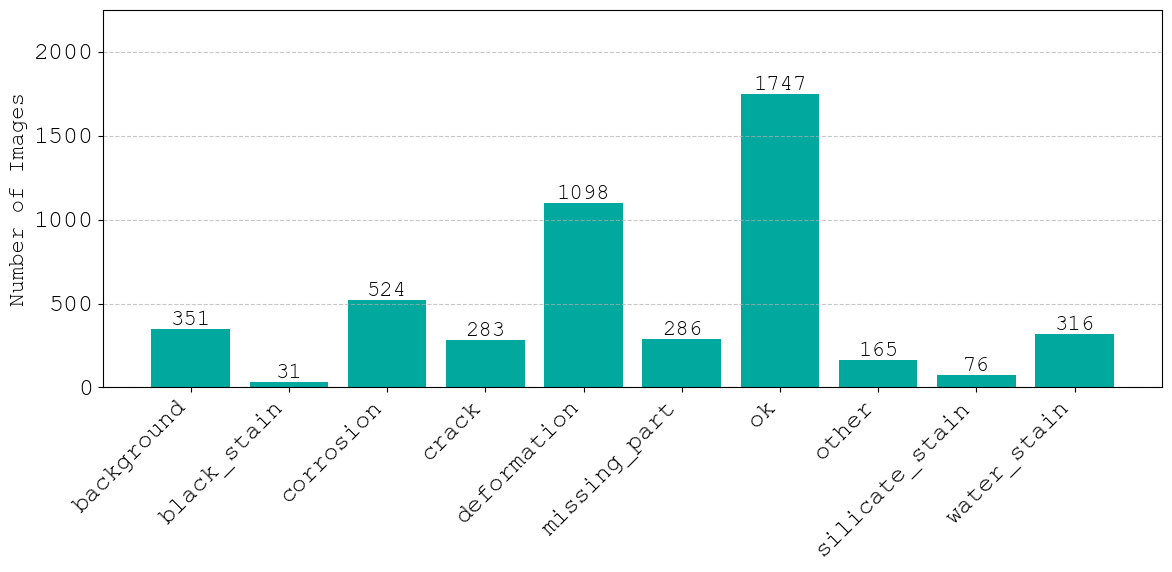

In [16]:
fig = plt.figure(figsize=(12, 6))

x = np.arange(len(labels))

plt.bar(x=x, height=[np.sum(noisy_targets == i) for i in range(noisy_num_classes)], color=(0.0, 0.66, 0.62))
for i in range(noisy_num_classes):
    plt.text(i, np.sum(noisy_targets == i), str(np.sum(noisy_targets == i)), ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(np.arange(0, 2250, 500))
plt.ylim(0, 2250)
plt.xticks(np.arange(0, noisy_num_classes), labels, rotation=45, ha='right')
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("plots/class_distribution_noisy.svg", bbox_inches='tight')
plt.show()

## Clustering the noisy data

Clustering the noisy data and splitting it in val and test

Cleaning val and test

In [17]:
from os import path

class_mapping = noisy_dataset.class_to_idx

noisy_clustered_path = BASE_DATA_PATH / "noisy_clustered"
noisy_clustered_dataset = {"samples": [], "targets": []}

for root, dirs, files in os.walk(noisy_clustered_path):
    for file in files:
        if file.endswith((".jpg", ".jpeg", ".png")):
            label = path.basename(root)
            file_path = path.join(root, file)
            noisy_clustered_dataset["samples"].append(file_path)
            noisy_clustered_dataset["targets"].append(class_mapping[label])

print("Noisy dataset: ", len(noisy_dataset.samples))
print("Noisy clustered dataset: ", len(noisy_clustered_dataset["samples"]))

noisy_clustered_targets = np.array(noisy_clustered_dataset["targets"])

Noisy dataset:  4877
Noisy clustered dataset:  4872


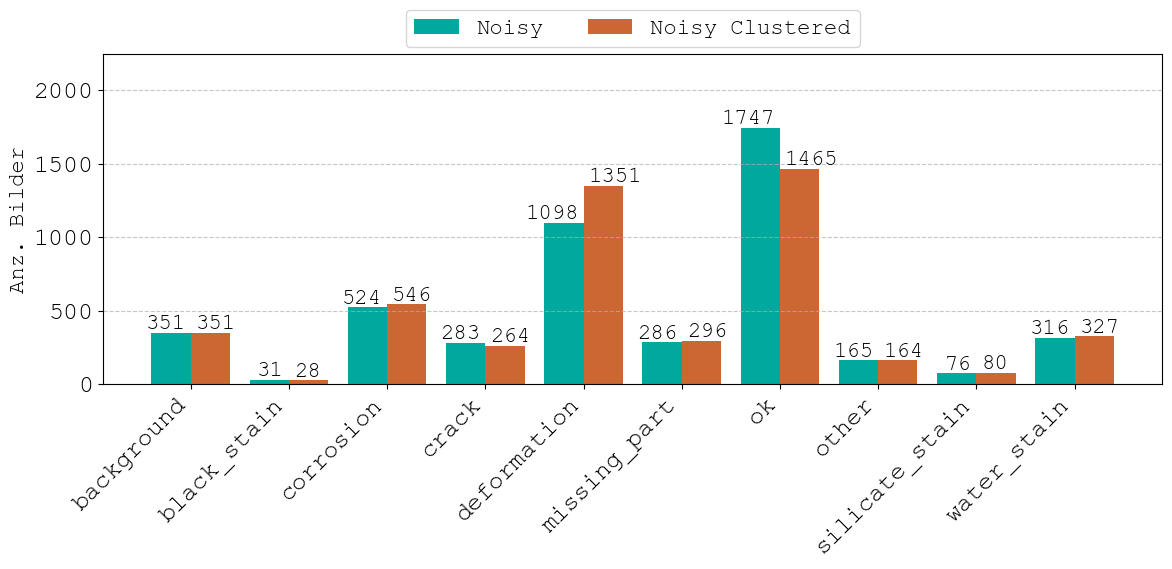

In [40]:
fig = plt.figure(figsize=(12, 6))

x = np.arange(len(labels))

plt.bar(x=x-0.2, height=[np.sum(noisy_targets == i) for i in range(noisy_num_classes)], label="Noisy", color=(0.0, 0.66, 0.62), width=0.4)
plt.bar(x=x+0.2, height=[np.sum(noisy_clustered_targets == i) for i in range(noisy_num_classes)], label="Noisy Clustered", color=(0.8, 0.4, 0.2), width=0.4)
for i in range(noisy_num_classes):
    plt.text(i-0.05, np.sum(noisy_targets == i), str(np.sum(noisy_targets == i)), ha='right', va='bottom')
    plt.text(i+0.05, np.sum(noisy_clustered_targets == i), str(np.sum(noisy_clustered_targets == i)), ha='left', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(np.arange(0, 2250, 500))
plt.ylim(0, 2250)
plt.xticks(np.arange(0, noisy_num_classes), labels, rotation=45, ha='right')
plt.ylabel("Anz. Bilder")
plt.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center',
                      ncols=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig("plots/class_distribution_noisy_vs_noisy_clustered.svg", bbox_inches='tight')
plt.show()

## Adding new captured data

In [19]:
noisy_clustered_with_new_path = BASE_DATA_PATH / "noisy_clustered_new"
noisy_clustered_with_new_dataset = {"samples": [], "targets": []}

for root, dirs, files in os.walk(noisy_clustered_with_new_path):
    for file in files:
        if file.endswith((".jpg", ".jpeg", ".png")):
            label = path.basename(root)
            file_path = path.join(root, file)
            noisy_clustered_with_new_dataset["samples"].append(file_path)
            noisy_clustered_with_new_dataset["targets"].append(class_mapping[label])

print("Noisy clustered dataset: ", len(noisy_clustered_dataset["samples"]))
print("Noisy clusteredwith new dataset: ", len(noisy_clustered_with_new_dataset["samples"]))

noisy_clustered_new_targets = np.array(noisy_clustered_with_new_dataset["targets"])

Noisy clustered dataset:  4872
Noisy clusteredwith new dataset:  5796


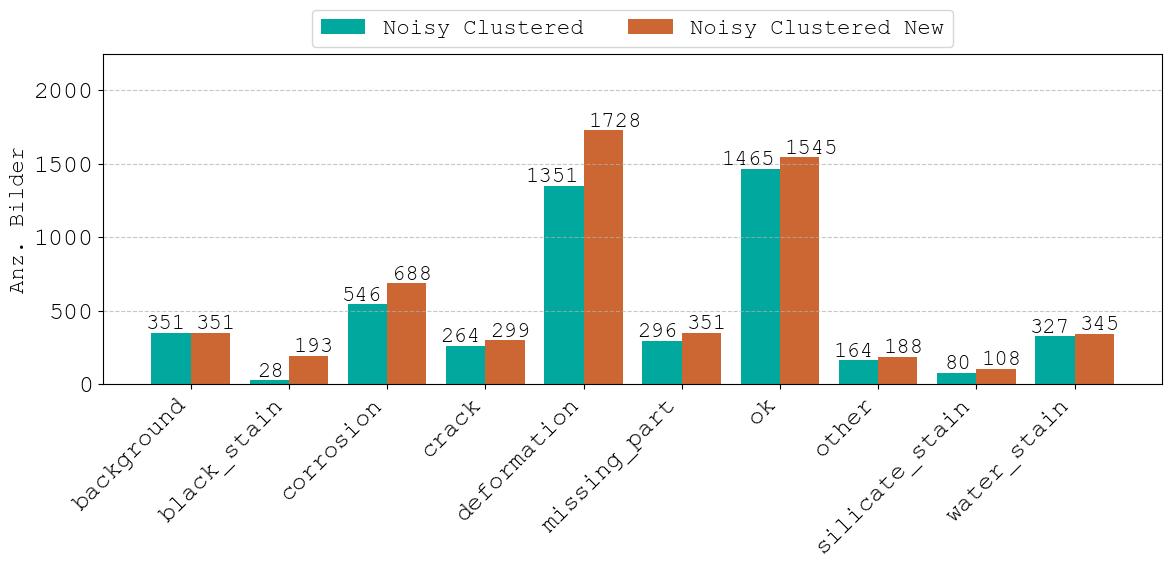

In [41]:
fig = plt.figure(figsize=(12, 6))

x = np.arange(len(labels))

plt.bar(x=x-0.2, height=[np.sum(noisy_clustered_targets == i) for i in range(noisy_num_classes)], label="Noisy Clustered", color=(0.0, 0.66, 0.62), width=0.4)
plt.bar(x=x+0.2, height=[np.sum(noisy_clustered_new_targets == i) for i in range(noisy_num_classes)], label="Noisy Clustered New", color=(0.8, 0.4, 0.2), width=0.4)
for i in range(noisy_num_classes):
    plt.text(i-0.05, np.sum(noisy_clustered_targets == i), str(np.sum(noisy_clustered_targets == i)), ha='right', va='bottom')
    plt.text(i+0.05, np.sum(noisy_clustered_new_targets == i), str(np.sum(noisy_clustered_new_targets == i)), ha='left', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(np.arange(0, 2250, 500))
plt.ylim(0, 2250)
plt.xticks(np.arange(0, noisy_num_classes), labels, rotation=45, ha='right')
plt.ylabel("Anz. Bilder")
plt.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center',
                      ncols=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig("plots/class_distribution_noisy_clustered_vs_with_new.svg", bbox_inches='tight')
plt.show()

## Performance of robust learning algorithms

### Baseline


In [21]:
BASE_LOGS_PATH = pathlib.Path("../logs/train/SurfaceDefectDetection")

In [22]:
def get_metrics_df(log_dir):
    training_statistics = pd.read_csv(log_dir / "val_summary/summary_statistics.csv")
    metrics_df = training_statistics.copy()
    macro_metrics = metrics_df[metrics_df["metric"].astype(str).str.endswith("macro")]
    weighted_metrics = metrics_df[metrics_df["metric"].astype(str).str.endswith("weighted")]
    macro_weighted_metrics = pd.concat([macro_metrics, weighted_metrics])
    macro_weighted_metrics.sort_values(by=["metric"], inplace=True, ascending=True)
    macro_weighted_metrics.reset_index(drop=True, inplace=True)
    return macro_weighted_metrics



STAT_COLS = ["mean", "median", "std", "ci_lower", "ci_upper", "min", "max"]

def class_prf_all_stats(log_dir, split="val", metrics=("f1", "precision", "recall")):
    df = pd.read_csv(log_dir / "val_summary/summary_statistics.csv")
    m = df["metric"].astype(str)

    metric_union = "|".join(metrics)
    pat = rf"^{split}/({metric_union})_(.+)$"

    # keep only per-class PRF rows (exclude macro/weighted)
    cls = df[m.str.match(pat, na=False) & ~m.str.endswith(("_macro", "_weighted"), na=False)].copy()

    cls[["metric_type", "class_name"]] = cls["metric"].str.extract(pat)

    # keep only what you care about, ordered nicely
    cols = ["class_name", "metric_type", *STAT_COLS]
    cls = cls[cols].sort_values(["metric_type", "class_name"]).reset_index(drop=True)

    return cls

In [23]:
baseline_metrics = get_metrics_df(BASE_LOGS_PATH / "noisy_new/2026-02-24_05-32-10_ce")
baseline_class_metrics = class_prf_all_stats(BASE_LOGS_PATH / "noisy_new/2026-02-24_05-32-10_ce")
baseline_metrics

,metric,mean,median,std,ci_lower,ci_upper,min,max
0,val/f1_macro,0.652247,0.650524,0.012133,0.643568,0.660927,0.635021,0.674170
1,val/f1_weighted,0.625369,0.623442,0.018332,0.612255,0.638483,0.595049,0.656497
2,val/precision_macro,0.688561,0.693952,0.016318,0.676888,0.700234,0.662213,0.710341
3,val/precision_weighted,0.694713,0.699804,0.026829,0.675521,0.713905,0.628953,0.728122
4,val/recall_macro,0.668605,0.669869,0.013473,0.658967,0.678243,0.637548,0.684923
5,val/recall_weighted,0.620713,0.618040,0.017865,0.607933,0.633493,0.592428,0.648107


In [24]:
sce_metrics = get_metrics_df(BASE_LOGS_PATH / "noisy_new/2026-02-24_16-47-40_sce")
sce_class_metrics = class_prf_all_stats(BASE_LOGS_PATH / "noisy_new/2026-02-24_16-47-40_sce")
sce_metrics

,metric,mean,median,std,ci_lower,ci_upper,min,max
0,val/f1_macro,0.678511,0.679743,0.017642,0.665891,0.691131,0.646701,0.702353
1,val/f1_weighted,0.641097,0.643452,0.020255,0.626607,0.655587,0.606616,0.667775
2,val/precision_macro,0.722491,0.726637,0.019944,0.708223,0.736758,0.695897,0.756793
3,val/precision_weighted,0.711753,0.715031,0.020861,0.696830,0.726677,0.678949,0.743217
4,val/recall_macro,0.687722,0.688015,0.020792,0.672848,0.702596,0.651057,0.710272
5,val/recall_weighted,0.636192,0.637528,0.020031,0.621862,0.650521,0.603563,0.663697


In [25]:
nce_rce_metrics = get_metrics_df(BASE_LOGS_PATH / "noisy_new/2026-02-25_08-05-00_nce_rce")
nce_rce_class_metrics = class_prf_all_stats(BASE_LOGS_PATH / "noisy_new/2026-02-25_08-05-00_nce_rce")
nce_rce_metrics

,metric,mean,median,std,ci_lower,ci_upper,min,max
0,val/f1_macro,0.661743,0.660910,0.012314,0.652934,0.670552,0.637592,0.683053
1,val/f1_weighted,0.627758,0.639688,0.021374,0.612468,0.643048,0.582662,0.647782
2,val/precision_macro,0.706319,0.708942,0.022329,0.690346,0.722292,0.663937,0.731427
3,val/precision_weighted,0.680262,0.689416,0.032493,0.657018,0.703506,0.612760,0.715044
4,val/recall_macro,0.672840,0.677281,0.022345,0.656855,0.688825,0.634492,0.703638
5,val/recall_weighted,0.626281,0.637528,0.020861,0.611358,0.641204,0.581292,0.646993


In [26]:
mixup_metrics = get_metrics_df(BASE_LOGS_PATH / "noisy_new_mixup/2026-02-24_15-23-55_mixup")
mixup_class_metrics = class_prf_all_stats(BASE_LOGS_PATH / "noisy_new_mixup/2026-02-24_15-23-55_mixup")
mixup_metrics

,metric,mean,median,std,ci_lower,ci_upper,min,max
0,val/f1_macro,0.680574,0.682754,0.012511,0.671625,0.689524,0.659685,0.697897
1,val/f1_weighted,0.655120,0.652682,0.010559,0.647567,0.662673,0.638292,0.675773
2,val/precision_macro,0.752105,0.760222,0.022888,0.735732,0.768478,0.705644,0.776233
3,val/precision_weighted,0.718722,0.724361,0.018795,0.705277,0.732167,0.676416,0.743652
4,val/recall_macro,0.672583,0.673824,0.016074,0.661084,0.684081,0.650529,0.696329
5,val/recall_weighted,0.650780,0.649777,0.011623,0.642465,0.659094,0.633630,0.673719


In [27]:
cutmix_metrics = get_metrics_df(BASE_LOGS_PATH / "noisy_new_cutmix/2026-02-26_08-18-38_cutmix")
cutmix_class_metrics = class_prf_all_stats(BASE_LOGS_PATH / "noisy_new_cutmix/2026-02-26_08-18-38_cutmix")
cutmix_metrics

,metric,mean,median,std,ci_lower,ci_upper,min,max
0,val/f1_macro,0.670553,0.671917,0.021607,0.655096,0.686009,0.643103,0.698234
1,val/f1_weighted,0.640490,0.642295,0.019229,0.626734,0.654246,0.604844,0.663977
2,val/precision_macro,0.723824,0.712737,0.021993,0.708091,0.739557,0.697993,0.759633
3,val/precision_weighted,0.698878,0.696910,0.016506,0.687070,0.710686,0.674937,0.721264
4,val/recall_macro,0.681884,0.681344,0.020078,0.667521,0.696247,0.647184,0.709111
5,val/recall_weighted,0.638196,0.639198,0.020185,0.623757,0.652635,0.605791,0.662584


In [28]:
nal_metrics = get_metrics_df(BASE_LOGS_PATH / "noisy_new_nal/2026-02-25_22-18-50_precomputed")
nal_class_metrics = class_prf_all_stats(BASE_LOGS_PATH / "noisy_new_nal/2026-02-25_22-18-50_precomputed")
nal_metrics

,metric,mean,median,std,ci_lower,ci_upper,min,max
0,val/f1_macro,0.692951,0.698440,0.014055,0.682896,0.703006,0.665975,0.705158
1,val/f1_weighted,0.658708,0.662587,0.016801,0.646689,0.670726,0.624798,0.675609
2,val/precision_macro,0.727609,0.731222,0.023187,0.711023,0.744196,0.685094,0.759341
3,val/precision_weighted,0.726811,0.732810,0.021866,0.711168,0.742453,0.678235,0.753797
4,val/recall_macro,0.704521,0.703393,0.013048,0.695186,0.713855,0.682595,0.724085
5,val/recall_weighted,0.655234,0.658129,0.015993,0.643793,0.666675,0.624722,0.671492


# Creating a cleaned dataset by hand

In [29]:
clean_clustered_with_new_path = BASE_DATA_PATH / "full_clean_clustered_new"
clean_clustered_with_new_dataset = {"samples": [], "targets": []}

for root, dirs, files in os.walk(clean_clustered_with_new_path):
    for file in files:
        if file.endswith((".jpg", ".jpeg", ".png")):
            label = path.basename(root)
            file_path = path.join(root, file)
            clean_clustered_with_new_dataset["samples"].append(file_path)
            clean_clustered_with_new_dataset["targets"].append(class_mapping[label])

print("Noisy clustered with new dataset: ", len(noisy_clustered_with_new_dataset["samples"]))
print("Clean clustered with new dataset: ", len(clean_clustered_with_new_dataset["samples"]))

clean_clustered_new_targets = np.array(clean_clustered_with_new_dataset["targets"])

Noisy clustered with new dataset:  5796
Clean clustered with new dataset:  5792


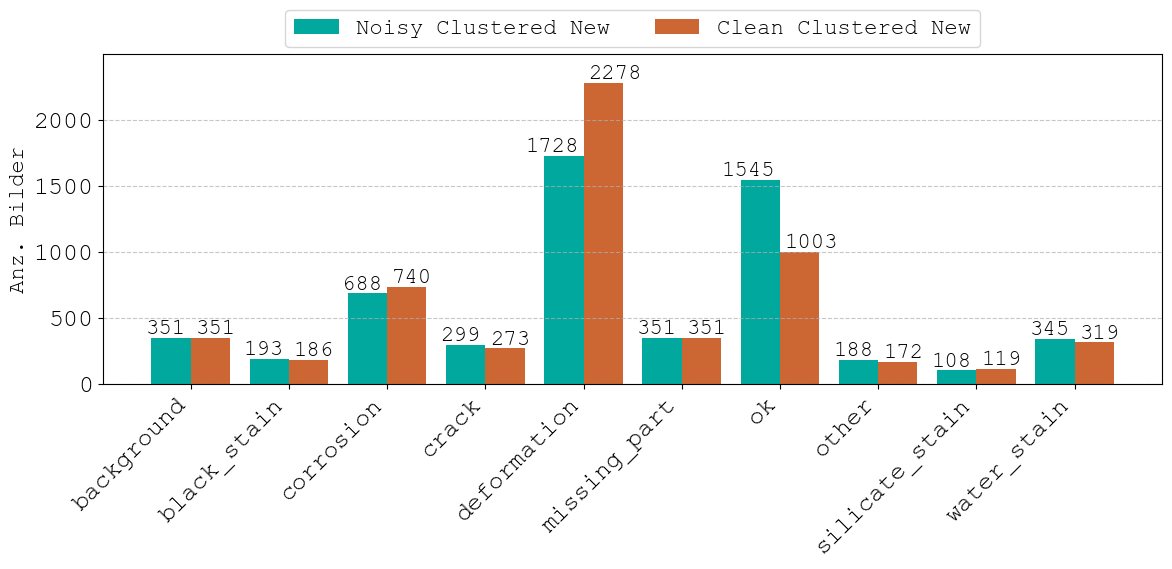

In [42]:
fig = plt.figure(figsize=(12, 6))

x = np.arange(len(labels))

plt.bar(x=x-0.2, height=[np.sum(noisy_clustered_new_targets == i) for i in range(noisy_num_classes)], label="Noisy Clustered New", color=(0.0, 0.66, 0.62), width=0.4)
plt.bar(x=x+0.2, height=[np.sum(clean_clustered_new_targets == i) for i in range(noisy_num_classes)], label="Clean Clustered New", color=(0.8, 0.4, 0.2), width=0.4)
for i in range(noisy_num_classes):
    plt.text(i-0.05, np.sum(noisy_clustered_new_targets == i), str(np.sum(noisy_clustered_new_targets == i)), ha='right', va='bottom')
    plt.text(i+0.05, np.sum(clean_clustered_new_targets == i), str(np.sum(clean_clustered_new_targets == i)), ha='left', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(np.arange(0, 2500, 500))
plt.ylim(0, 2500)
plt.xticks(np.arange(0, noisy_num_classes), labels, rotation=45, ha='right')
plt.ylabel("Anz. Bilder")
plt.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower center',
                      ncols=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig("plots/class_distribution_noisy_new_vs_clean_new.svg", bbox_inches='tight')
plt.show()

## Noise estimation through confusion matrix

In [31]:
noisy_images = []
for img_path, _ in noisy_dataset.samples:
    label = path.basename(path.dirname(img_path))
    img = Image.open(img_path)
    image_id = md5(img.tobytes()).hexdigest()
    noisy_images.append({"id": image_id, "label": label})

noisy_df = pd.DataFrame(noisy_images)

In [32]:
clean_dataset = ImageFolder(BASE_DATA_PATH / "full_clean")
clean_images = []
for img_path, _ in clean_dataset.samples:
    label = path.basename(path.dirname(img_path))
    img = Image.open(img_path)
    image_id = md5(img.tobytes()).hexdigest()
    clean_images.append({"id": image_id, "label": label})

clean_df = pd.DataFrame(clean_images)

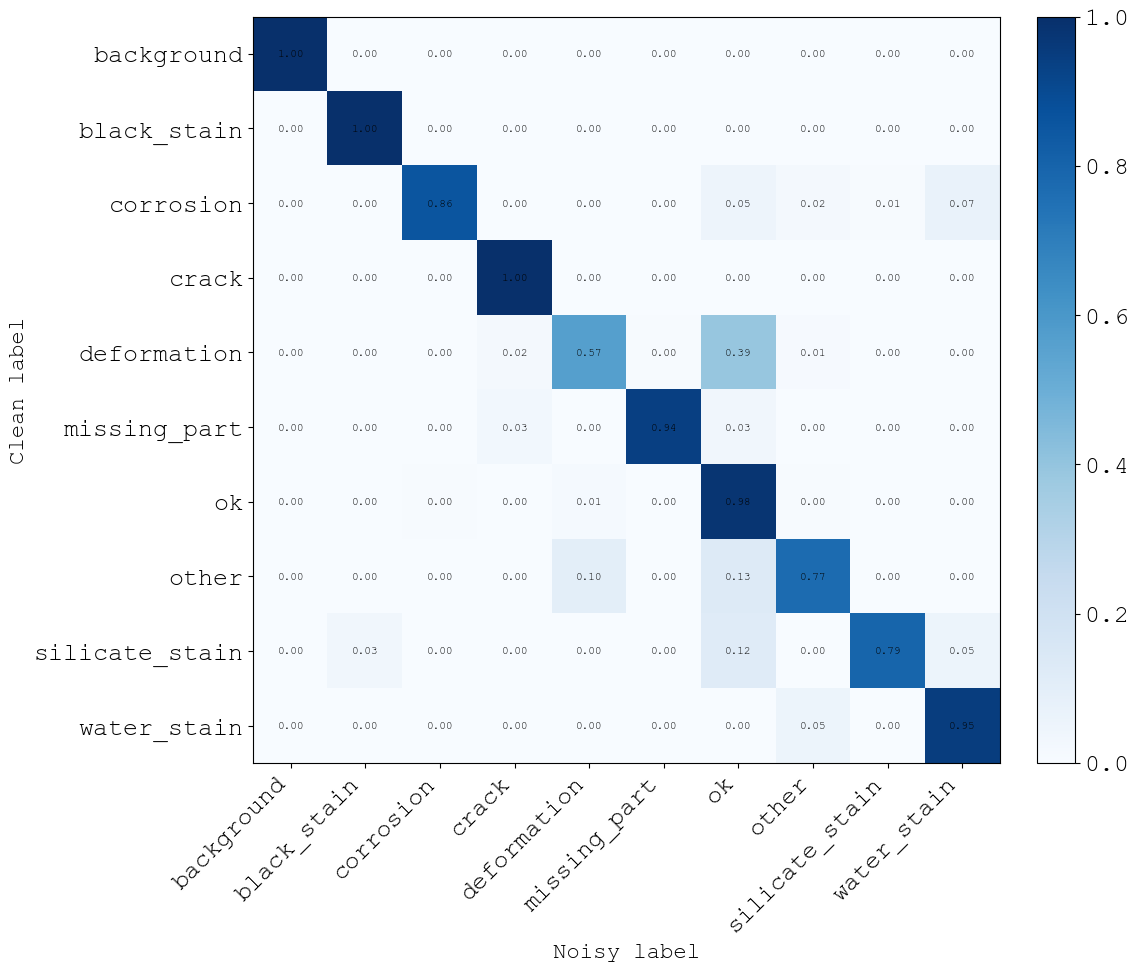

noisy,background,black_stain,corrosion,crack,deformation,missing_part,ok,other,silicate_stain,water_stain
clean,,,,,,,,,,
background,351,0,0,0,0,0,0,0,0,0
black_stain,0,24,0,0,0,0,0,0,0,0
corrosion,0,2,513,0,0,0,29,11,3,40
crack,0,0,0,231,0,0,0,0,0,0
deformation,0,0,5,43,1072,9,746,20,0,0
missing_part,0,0,0,8,0,274,10,0,0,0
ok,0,0,4,0,11,0,904,4,0,0
other,0,0,0,0,15,0,19,114,0,0
silicate_stain,0,3,0,0,0,0,11,0,73,5


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Align noisy and clean labels by image id
merged_df = noisy_df.merge(clean_df, on="id", how="inner", suffixes=("_noisy", "_clean"))
if merged_df.empty:
    raise ValueError("No overlapping image ids between noisy_df and clean_df.")

# Confusion matrix: clean (rows) vs noisy (cols)
labels = sorted(set(merged_df["label_clean"]) | set(merged_df["label_noisy"]))
conf_counts = pd.crosstab(
    merged_df["label_clean"],
    merged_df["label_noisy"],
    rownames=["clean"],
    colnames=["noisy"],
    dropna=False,
).reindex(index=labels, columns=labels, fill_value=0)

# Row-normalized confusion matrix (noise rates)
conf_rates = conf_counts.div(conf_counts.sum(axis=1).replace(0, np.nan), axis=0)

fig, ax = plt.subplots(figsize=(1.2 * len(labels), 1.0 * len(labels)))
im = ax.imshow(conf_rates.values, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Noisy label")
ax.set_ylabel("Clean label")

# Annotate with rates
for i in range(len(labels)):
    for j in range(len(labels)):
        val = conf_rates.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("plots/noise_confusion_matrix.svg", bbox_inches="tight")
plt.show()

# Also show raw counts for reference
conf_counts

## Performance of baseline algorithms on the cleaned dataset

In [35]:
clean_ce_metrics = get_metrics_df(BASE_LOGS_PATH / "clean/2026-02-23_23-25-34_ce_mobile_s")
clean_ce_class_metrics = class_prf_all_stats(BASE_LOGS_PATH / "clean/2026-02-23_23-25-34_ce_mobile_s")
clean_ce_metrics

,metric,mean,median,std,ci_lower,ci_upper,min,max
0,val/f1_macro,0.777862,0.777647,0.009360,0.771166,0.784558,0.761922,0.789290
1,val/f1_weighted,0.796518,0.795795,0.012430,0.787626,0.805410,0.775288,0.817182
2,val/precision_macro,0.821845,0.818431,0.018897,0.808327,0.835363,0.794591,0.862037
3,val/precision_weighted,0.812006,0.812167,0.011410,0.803844,0.820168,0.795158,0.834787
4,val/recall_macro,0.768595,0.766454,0.017525,0.756058,0.781131,0.735403,0.793944
5,val/recall_weighted,0.798111,0.798889,0.013095,0.788743,0.807479,0.775556,0.818889


In [36]:
clean_ce_class_metrics

,class_name,metric_type,mean,median,std,ci_lower,ci_upper,min,max
0,background,f1,0.916416,0.916660,0.020357,0.901853,0.930979,0.875000,0.953271
1,black_stain,f1,0.798808,0.824292,0.074717,0.745359,0.852257,0.658824,0.888889
2,corrosion,f1,0.751168,0.763227,0.045400,0.718691,0.783645,0.654545,0.818182
3,crack,f1,0.697085,0.692255,0.043774,0.665771,0.728399,0.642857,0.767123
4,deformation,f1,0.874302,0.871003,0.019003,0.860709,0.887896,0.854167,0.910405
5,missing_part,f1,0.816175,0.824561,0.032423,0.792981,0.839369,0.745455,0.849558
6,ok,f1,0.684739,0.687752,0.016550,0.672900,0.696578,0.662857,0.706849
7,other,f1,0.852638,0.844137,0.032654,0.829279,0.875998,0.809524,0.909091
8,silicate_stain,f1,0.567039,0.563721,0.027938,0.547053,0.587024,0.538462,0.618182
9,water_stain,f1,0.820251,0.825841,0.025143,0.802265,0.838238,0.771429,0.849315


## Run comparison

In [ ]:
import itertools
import math
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from scipy import stats as _stats
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False


def _t_crit_975(df: int) -> float:
    if _HAS_SCIPY:
        return float(_stats.t.ppf(0.975, df))
    # Fallback table for df=1..30 at 0.975 (two-sided 95% CI).
    t_table = {
        1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571,
        6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262, 10: 2.228,
        11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145, 15: 2.131,
        16: 2.120, 17: 2.110, 18: 2.101, 19: 2.093, 20: 2.086,
        21: 2.080, 22: 2.074, 23: 2.069, 24: 2.064, 25: 2.060,
        26: 2.056, 27: 2.052, 28: 2.048, 29: 2.045, 30: 2.042,
    }
    if df in t_table:
        return t_table[df]
    return 1.96


def _sign_flip_test(d: np.ndarray) -> dict:
    d = np.asarray(d, dtype=float)
    n = d.size
    obs = float(d.mean())
    exact = True
    if n <= 20:
        signs = np.array(list(itertools.product([1.0, -1.0], repeat=n)))
        perm = (signs * d).mean(axis=1)
    else:
        exact = False
        rng = np.random.default_rng(0)
        m = 200000
        signs = rng.choice([-1.0, 1.0], size=(m, n))
        perm = (signs * d).mean(axis=1)
    p_one = float(np.mean(perm >= obs))
    p_two = float(np.mean(np.abs(perm) >= abs(obs)))
    return {"p_one_sided": p_one, "p_two_sided": p_two, "exact": exact, "n_perm": len(perm)}


def compare_paired_f1(f1_A, f1_B, name_A="A", name_B="B", run_idx=None, show_table=True):
    a = np.asarray(f1_A, dtype=float)
    b = np.asarray(f1_B, dtype=float)
    if a.shape != b.shape:
        raise ValueError(f"Length mismatch: {name_A} has {a.size}, {name_B} has {b.size}")
    if a.size < 2:
        raise ValueError("Need at least two paired runs (n >= 2)")
    if np.isnan(a).any() or np.isnan(b).any():
        raise ValueError("NaNs found in inputs")
    if run_idx is None:
        run_idx = np.arange(a.size)
    if len(run_idx) != a.size:
        raise ValueError("run_idx length mismatch")
    d = b - a
    mean_a = float(a.mean())
    sd_a = float(a.std(ddof=1))
    mean_b = float(b.mean())
    sd_b = float(b.std(ddof=1))
    mean_d = float(d.mean())
    sd_d = float(d.std(ddof=1))
    se_d = sd_d / math.sqrt(a.size)
    t_crit = _t_crit_975(a.size - 1)
    ci_low = mean_d - t_crit * se_d
    ci_high = mean_d + t_crit * se_d
    sign_test = _sign_flip_test(d)
    print(f"Paired comparison: {name_B} vs {name_A}")
    print(f"n = {a.size}")
    print(f"Mean({name_A}) = {mean_a:.6f}, SD({name_A}) = {sd_a:.6f}")
    print(f"Mean({name_B}) = {mean_b:.6f}, SD({name_B}) = {sd_b:.6f}")
    print(f"Mean paired improvement Δ = {mean_d:.6f}, SD(d) = {sd_d:.6f}")
    print(f"95% CI for Δ (t, df={a.size - 1}): [{ci_low:.6f}, {ci_high:.6f}]")
    exact_label = "exact" if sign_test["exact"] else "MC"
    print(
        "Sign-flip test:",
        f"p_one_sided={sign_test['p_one_sided']:.6f}",
        f"p_two_sided={sign_test['p_two_sided']:.6f}",
        f"({exact_label}, n_perm={sign_test['n_perm']})",
    )
    if _HAS_SCIPY:
        t_res = _stats.ttest_rel(b, a, alternative="greater")
        try:
            w_res = _stats.wilcoxon(d, alternative="greater")
        except ValueError as exc:
            w_res = exc
        print("Paired t-test (greater):", t_res)
        print("Wilcoxon signed-rank (greater):", w_res)
    summary = {
        "n": a.size,
        "mean_A": mean_a,
        "sd_A": sd_a,
        "mean_B": mean_b,
        "sd_B": sd_b,
        "mean_d": mean_d,
        "sd_d": sd_d,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_one_sided": sign_test["p_one_sided"],
        "p_two_sided": sign_test["p_two_sided"],
        "signflip_exact": sign_test["exact"],
    }
    if show_table:
        df = pd.DataFrame({
            "run_idx": run_idx,
            f"f1_{name_A}": a,
            f"f1_{name_B}": b,
            "d": d,
        })
        display(df)
    print("""\nSummary (thesis-ready)
Δ = {mean_d:.6f}
95% CI = [{ci_low:.6f}, {ci_high:.6f}]
p_one_sided = {p_one:.6f}
p_two_sided = {p_two:.6f}
n = {n}\n""".format(
        mean_d=mean_d, ci_low=ci_low, ci_high=ci_high,
        p_one=sign_test["p_one_sided"], p_two=sign_test["p_two_sided"], n=a.size
    ))
    return summary


def _select_overall_f1_column(df: pd.DataFrame) -> str:
    candidates = ["f1", "f1_macro", "f1_mean", "f1_avg", "f1_micro", "f1_weighted"]
    cols_lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in cols_lower:
            return cols_lower[c]
    f1_cols = [c for c in df.columns if "f1" in c.lower()]
    if not f1_cols:
        raise ValueError("No F1 columns found")
    return f1_cols[0]


def _class_f1_columns(df: pd.DataFrame, overall_col: str) -> list:
    skip_tokens = ["macro", "micro", "weighted", "avg", "mean", "overall"]
    cols = [c for c in df.columns if "f1" in c.lower()]
    class_cols = []
    for c in cols:
        if c == overall_col:
            continue
        lc = c.lower()
        if any(tok in lc for tok in skip_tokens):
            continue
        class_cols.append(c)
    return class_cols


@dataclass(frozen=True)
class RunSpec:
    name: str
    metrics_path: Path


def _load_run_metrics(run: RunSpec) -> pd.DataFrame:
    df = pd.read_csv(run.metrics_path)
    if df.empty:
        raise ValueError(f"Empty metrics file: {run.metrics_path}")
    return df


def _align_runs(df_a: pd.DataFrame, df_b: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray]:
    if "run_idx" in df_a.columns and "run_idx" in df_b.columns:
        merged = df_a.merge(df_b, on="run_idx", suffixes=("_A", "_B"))
        run_idx = merged["run_idx"].to_numpy()
        df_a = merged[[c for c in merged.columns if c.endswith("_A")]]
        df_b = merged[[c for c in merged.columns if c.endswith("_B")]]
        df_a.columns = [c[:-2] for c in df_a.columns]
        df_b.columns = [c[:-2] for c in df_b.columns]
        return df_a, df_b, run_idx
    if len(df_a) != len(df_b):
        raise ValueError(f"Row count mismatch: {len(df_a)} vs {len(df_b)}")
    run_idx = np.arange(len(df_a))
    return df_a, df_b, run_idx


def compare_runs(run_a: RunSpec, run_b: RunSpec, show_tables=True) -> dict:
    df_a = _load_run_metrics(run_a)
    df_b = _load_run_metrics(run_b)
    df_a, df_b, run_idx = _align_runs(df_a, df_b)
    overall_a = _select_overall_f1_column(df_a)
    overall_b = _select_overall_f1_column(df_b)
    f1_a = pd.to_numeric(df_a[overall_a], errors="coerce")
    f1_b = pd.to_numeric(df_b[overall_b], errors="coerce")
    print(f"Overall F1 columns: {overall_a} ({run_a.name}), {overall_b} ({run_b.name})")
    overall_summary = compare_paired_f1(
        f1_a, f1_b, name_A=run_a.name, name_B=run_b.name, run_idx=run_idx, show_table=show_tables
    )
    class_cols_a = _class_f1_columns(df_a, overall_a)
    class_cols_b = _class_f1_columns(df_b, overall_b)
    common_class_cols = [c for c in class_cols_a if c in class_cols_b]
    per_class_rows = []
    if not common_class_cols:
        print("No common class-specific F1 columns found.")
    else:
        print("\nClass-specific F1 comparisons")
        for col in common_class_cols:
            f1_a_c = pd.to_numeric(df_a[col], errors="coerce")
            f1_b_c = pd.to_numeric(df_b[col], errors="coerce")
            print(f"\nClass F1: {col}")
            summary = compare_paired_f1(
                f1_a_c,
                f1_b_c,
                name_A=run_a.name,
                name_B=run_b.name,
                run_idx=run_idx,
                show_table=show_tables,
            )
            per_class_rows.append({
                "class_f1": col,
                "mean_d": summary["mean_d"],
                "sd_d": summary["sd_d"],
                "ci_low": summary["ci_low"],
                "ci_high": summary["ci_high"],
                "p_one_sided": summary["p_one_sided"],
                "p_two_sided": summary["p_two_sided"],
                "n": summary["n"],
            })
    if per_class_rows:
        display(pd.DataFrame(per_class_rows))
    return {"overall": overall_summary, "per_class": per_class_rows}

In [ ]:
comparisons = [
    # (
    #     RunSpec(
    #         name="noisy_new",
    #         metrics_path=Path("/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/noisy_new/2026-02-24_05-32-10_ce/summary/all_runs_metrics.csv"),
    #     ),
    #     RunSpec(
    #         name="clean",
    #         metrics_path=Path("/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/clean/2026-02-23_23-25-34_ce_mobile_s/summary/all_runs_metrics.csv"),
    #     ),
    # ),
    (
        RunSpec(
            name="noisy_new",
            metrics_path=Path("/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/noisy_new/2026-02-24_05-32-10_ce/summary/all_runs_metrics.csv"),
        ),
        RunSpec(
            name="noisy_sce",
            metrics_path=Path("/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/noisy_new/2026-02-24_16-47-40_sce/summary/all_runs_metrics.csv")
        )
    ),
    (
        RunSpec(
            name="noisy_new",
            metrics_path=Path("/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/noisy_new/2026-02-24_05-32-10_ce/summary/all_runs_metrics.csv"),
        ),
        RunSpec(
            name="noisy_mixup",
            metrics_path=Path("/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/noisy_new_mixup/2026-02-24_15-23-55_mixup/summary/all_runs_metrics.csv")
        )
    )
    # Add more tuples (run_a, run_b) here.
    # Example: (RunSpec("exp1", Path("/path/metrics1.csv")), RunSpec("exp2", Path("/path/metrics2.csv")))
 ]

all_results = []
for run_a, run_b in comparisons:
    print("\n" + "=" * 80)
    print(f"Comparison: {run_a.name} vs {run_b.name}")
    all_results.append({
        "run_a": run_a.name,
        "run_b": run_b.name,
        "results": compare_runs(run_a, run_b, show_tables=True),
    })